In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from datetime import datetime, timedelta

In [2]:
path_data = os.getcwd() + '/data/'
path_demand = path_data + 'output/csv/demand/'
path_loads =path_data + 'loads/'
path_generation = path_data + 'generators_profiles/'
path_losses = path_data + 'output/csv/losses/'
path_bess = path_data + 'output/csv/bess/'
dir_model = path_data + "/output/models/"

In [3]:
demand_NoOperation = path_demand + 'Demand_NoOperation_year_CondominioDosIpes.csv'
demand_RL = dir_model + 'demand_train.csv'
bess_Forecasting = path_bess + 'BessPowers_Forecasting_bus013_year_CondominioDosIpes.csv'
bess_RL = dir_model + 'bess_train.csv'

In [6]:
demand_values = pd.read_csv(demand_NoOperation)
demand_rl_values = pd.read_csv(demand_RL)
bess_rl_values = pd.read_csv(bess_RL)
bess_forecasting_values = pd.read_csv(bess_Forecasting)
bess_forecasting_values['Timestep'] = pd.to_datetime(bess_forecasting_values['Timestep'])
bess_rl_values['Timestep'] = pd.to_datetime(bess_rl_values['Timestep'])
demand_values['Timestep'] = pd.to_datetime(demand_values['Timestep'])
demand_rl_values['Timestep'] = pd.to_datetime(demand_rl_values['Timestep'])
# date_ini = '2012-07-08 06:05'
date_ini = '2012-07-07 12:00'
date_end = '2012-07-07 17:25'
time = pd.date_range(start=date_ini, end=date_end, freq='5min')
demand_values = demand_values[(demand_values['Timestep'] >= date_ini) & (demand_values['Timestep'] <= date_end)]
demand_rl_values = demand_rl_values[(demand_rl_values['Timestep'] >= date_ini) & (demand_rl_values['Timestep'] <= date_end)]
bess_rl_values = bess_rl_values[(bess_rl_values['Timestep'] >= date_ini) & (bess_rl_values['Timestep'] <= date_end)]
bess_forecasting_values = bess_forecasting_values[(bess_forecasting_values['Timestep'] >= date_ini) & (bess_forecasting_values['Timestep'] <= date_end)]



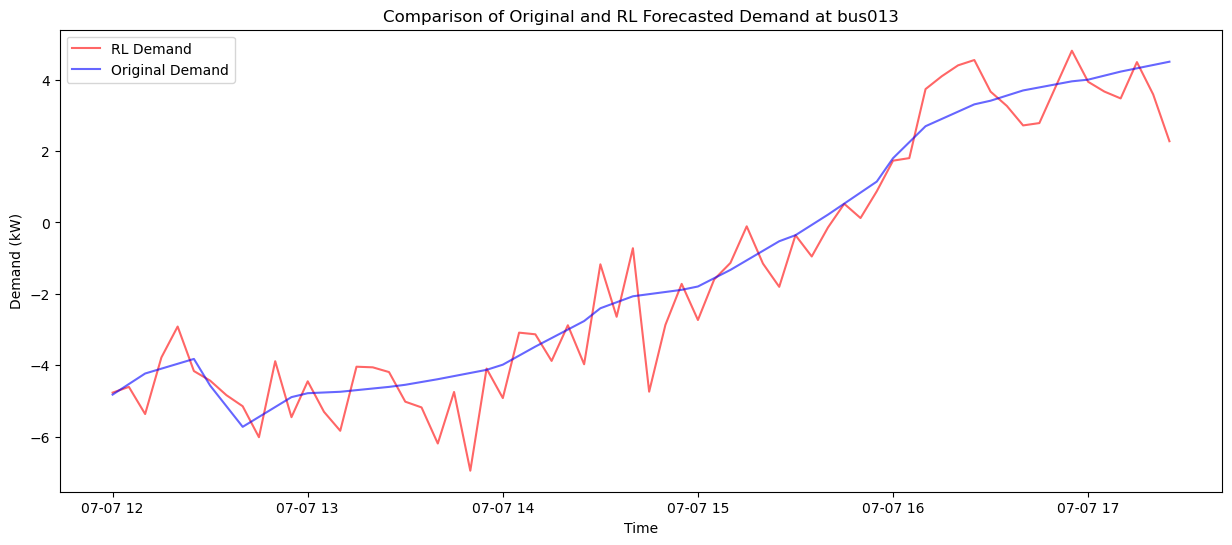

In [9]:
# plotting the demand values

plt.figure(figsize=(15, 6))
plt.plot(time, demand_rl_values['P(kW)'], label='RL Demand', color='red', alpha=0.6)
plt.plot(time, demand_values['P(kW)'], label='Original Demand', color='blue', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Demand (kW)')
plt.title('Comparison of Original and RL Forecasted Demand at bus013')
plt.legend()

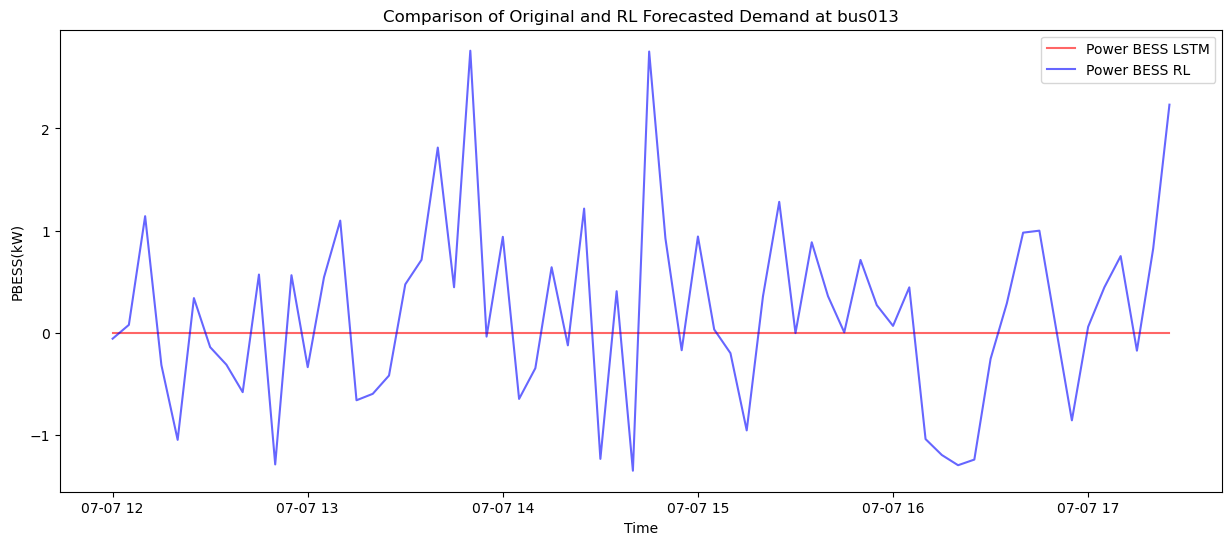

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(time, bess_forecasting_values['P(kW)'], label='Power BESS LSTM', color='red', alpha=0.6)
plt.plot(time, bess_rl_values['P(kW)'], label='Power BESS RL', color='blue', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('PBESS(kW)')
plt.title('Comparison of Original and RL Forecasted Demand at bus013')
plt.legend()